In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#Upload Dataset
from google.colab import files

uploaded = files.upload()

Saving manufacturing_dataset_1000_samples.csv to manufacturing_dataset_1000_samples.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 19)


In [4]:
#View the dataset
print("First 5 rows:")
display(df.head())

First 5 rows:


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


In [5]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
995,2023-02-11 11:00:00,211.6,131.1,39.2,10.2,400.0,26.2,10.4,3.3,32,Day,Type_C,Standard,Saturday,1.615,49.5,0.023,0.257,15.0
996,2023-02-11 12:00:00,236.6,114.6,22.8,11.3,348.3,21.2,12.0,67.6,43,Evening,Type_B,Standard,Thursday,2.064,34.2,0.442,0.159,49.6
997,2023-02-11 13:00:00,222.7,101.8,21.5,8.0,254.9,22.7,8.4,57.5,46,Evening,Type_C,Standard,Saturday,2.188,29.5,0.369,0.337,44.2
998,2023-02-11 14:00:00,300.0,112.6,26.7,10.2,122.6,21.1,9.3,120.0,48,Day,Type_A,Standard,Monday,1.849,36.8,0.760,0.291,57.7
999,2023-02-11 15:00:00,221.9,103.8,43.8,13.6,219.6,24.4,3.8,35.1,51,Day,Type_B,Economy,Monday,2.137,57.4,0.218,0.556,21.9


In [6]:
#Check daatset information
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows and columns:
(1000, 19)

Column names:
['Timestamp', 'Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']

Data types:
Timestamp                      object
Injection_Temperature         float64
Injection_Pressure            float64
Cycle_Time                    float64
Cooling_Time                  float64
Material_Viscosity            float64
Ambient_Temperature           float64
Machine_Age                   float64
Operator_Experience           float64
Maintenance_Hours               int64
Shift                          object
Machine_Type                   object
Material_Grade                 object
Day_of_Week                    object
Temperature_Pressure_Ratio    float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   object 
 13  Day_of_Week                 1000 n

In [8]:
#Clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Timestamp', 'Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']


In [9]:
#Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Timestamp                      0
Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64


In [10]:
#Handle missing numerical values
numerical_missing = [
    "Material_Viscosity",
    "Ambient_Temperature",
    "Operator_Experience"
]

for col in numerical_missing:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Timestamp                     0
Injection_Temperature         0
Injection_Pressure            0
Cycle_Time                    0
Cooling_Time                  0
Material_Viscosity            0
Ambient_Temperature           0
Machine_Age                   0
Operator_Experience           0
Maintenance_Hours             0
Shift                         0
Machine_Type                  0
Material_Grade                0
Day_of_Week                   0
Temperature_Pressure_Ratio    0
Total_Cycle_Time              0
Efficiency_Score              0
Machine_Utilization           0
Parts_Per_Hour                0
dtype: int64


In [11]:
#Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 19)


In [13]:
#Hanadle timestamp
if "Timestamp" in df.columns:

    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        errors="coerce"
    )

    df["Hour"] = df["Timestamp"].dt.hour
    df["Day"] = df["Timestamp"].dt.day
    df["Month"] = df["Timestamp"].dt.month
    df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

    df = df.drop(columns=["Timestamp"])

print(df.head())

   Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
0                  221.0               136.0        28.7          13.6   
1                  213.3               128.9        34.5          14.0   
2                  222.8               115.9        19.9           9.5   
3                  233.3               105.3        39.2          13.1   
4                  212.2               125.5        45.0           9.9   

   Material_Viscosity  Ambient_Temperature  Machine_Age  Operator_Experience  \
0               375.5                 28.0          3.8                 11.2   
1               215.8                 22.6          6.8                  6.3   
2               307.0                 25.3          4.2                  9.6   
3               137.8                 26.0          9.2                  8.6   
4               298.2                 23.6          6.2                 23.0   

   Maintenance_Hours    Shift  ... Day_of_Week Temperature_Pressure_Ratio 

In [14]:
#Check categorical columns
categorical_features = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

for col in categorical_features:
    print("\n", col)
    print(df[col].unique())


 Shift
['Evening' 'Night' 'Day']

 Machine_Type
['Type_B' 'Type_A' 'Type_C']

 Material_Grade
['Economy' 'Standard' 'Premium']

 Day_of_Week
['Thursday' 'Wednesday' 'Monday' 'Saturday' 'Friday' 'Sunday' 'Tuesday']


In [15]:
#Feature Engineering
if "Temperature_Pressure_Ratio" not in df.columns:
    df["Temperature_Pressure_Ratio"] = (
        df["Injection_Temperature"] /
        df["Injection_Pressure"]
    )

print(df[[
    "Injection_Temperature",
    "Injection_Pressure",
    "Temperature_Pressure_Ratio"
]].head())

   Injection_Temperature  Injection_Pressure  Temperature_Pressure_Ratio
0                  221.0               136.0                       1.625
1                  213.3               128.9                       1.655
2                  222.8               115.9                       1.922
3                  233.3               105.3                       2.215
4                  212.2               125.5                       1.691


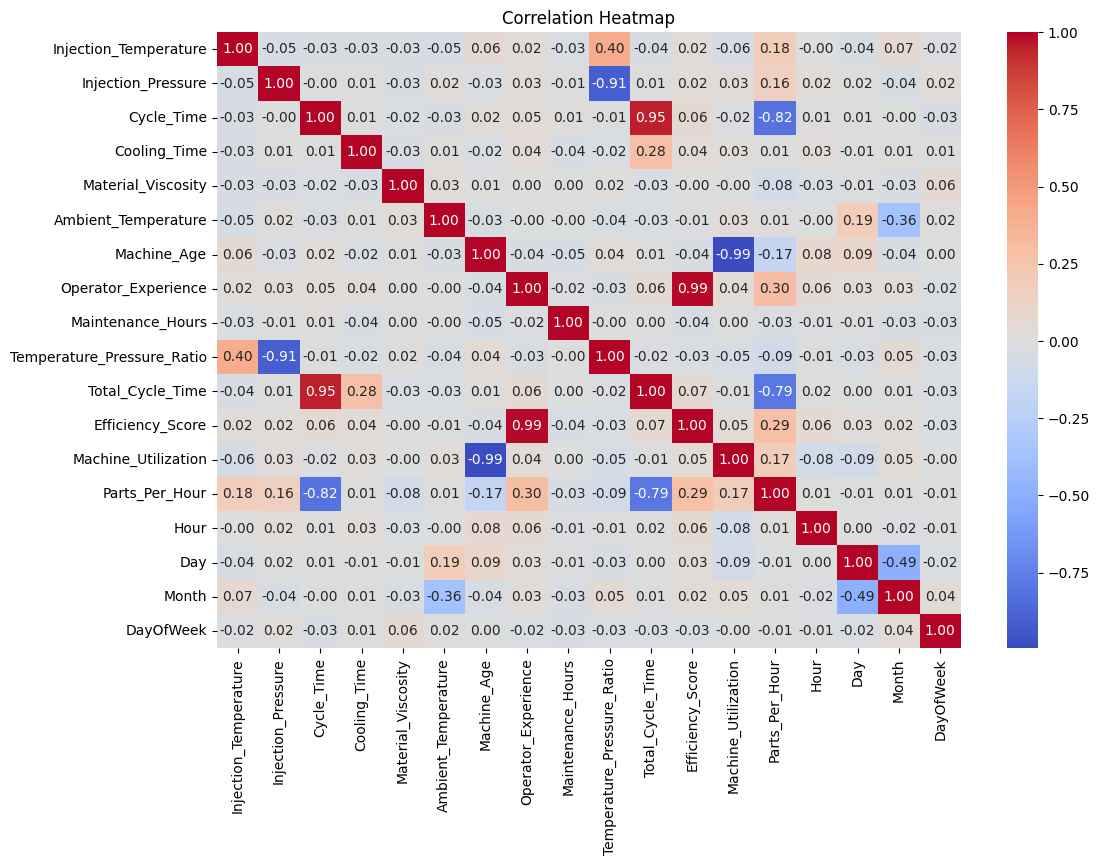

In [16]:
#EDA
plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

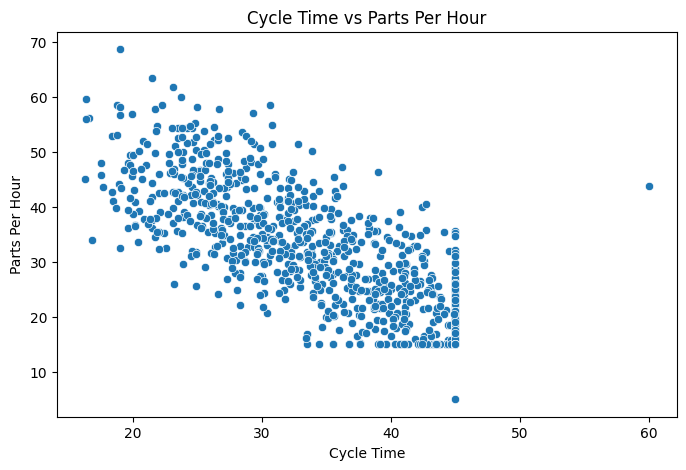

In [17]:
#Cycle Time Vs Parts Per Hour
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Cycle_Time",
    y="Parts_Per_Hour",
    data=df
)

plt.title("Cycle Time vs Parts Per Hour")
plt.xlabel("Cycle Time")
plt.ylabel("Parts Per Hour")
plt.show()

In [18]:
#Define X and y
X = df.drop(columns=["Parts_Per_Hour"])
y = df["Parts_Per_Hour"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 21)
Target shape: (1000,)


In [19]:
#Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization']

Categorical features:
['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']


In [20]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 21)
Testing data: (200, 21)


In [21]:
#Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [22]:
#Linear regression model
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
#Make predictions
y_pred = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[19.90144548 44.40674033 34.04829184 39.68794886 18.39489556 20.43304019
 33.54140901 14.11049651 27.97794689 32.3404188 ]


In [24]:
#Evaluate Linear Regression
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 2.7171493652641288
MSE : 12.304058592334044
RMSE: 3.5077141548783652
R²  : 0.9057108598984057


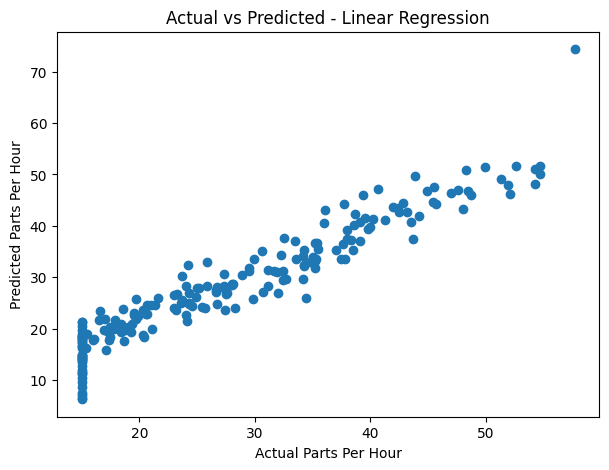

In [25]:
#Actual Vs Predicted graphs
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [26]:
#Save the trained model
import joblib

joblib.dump(
    linear_model,
    "manufacturing_linear_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [27]:
#Test the saved model
loaded_model = joblib.load(
    "manufacturing_linear_regression.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Predicted Parts Per Hour:", sample_prediction[0])

Predicted Parts Per Hour: 19.90144548429634
